# Airport flights in the Canary Islands (2004-2020)

**Dataset**: Operaciones en las islas de Canarias segun movimientos, servicios y territorios de origen/destino

**Source**: [ISTAC](https://datos.canarias.es) - monthly commercial flight operations by island

**Question**: How has airport traffic evolved across Canary Islands? Which islands have grown most? Gran Canaria vs Tenerife?

In [1]:
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = "data/raw/airport-flights-canary-islands.csv"
df = pd.read_csv(CSV_PATH)
print("Rows:", len(df), "| Columns:", len(df.columns))
df.head(2)

Rows: 167424 | Columns: 16


,AEROPUERTO_ORIGEN_DESTINO#es,AEROPUERTO_ORIGEN_DESTINO_CODE,SERVICIO_AEREO#es,SERVICIO_AEREO_CODE,MEDIDAS#es,MEDIDAS_CODE,MOVIMIENTO_AERONAVE#es,MOVIMIENTO_AERONAVE_CODE,AEROPUERTO_BASE#es,AEROPUERTO_BASE_CODE,TIME_PERIOD#es,TIME_PERIOD_CODE,OBS_VALUE,CONFIDENCIALIDAD_OBSERVACION#es,ESTADO_OBSERVACION#es,ESTADO_OBSERVACION_CODE
0,España (excluida Canarias),ES_XES70,Otros servicios comerciales,COMMERCIAL_O,Operaciones,OPERACIONES,Salida,DEPARTURE,La Palma,ES707,04/2012,2012-M04,NaN,NaN,NaN,NaN
1,España (excluida Canarias),ES_XES70,Otros servicios comerciales,COMMERCIAL_O,Operaciones,OPERACIONES,Salida,DEPARTURE,La Palma,ES707,05/2012,2012-M05,NaN,NaN,NaN,NaN


In [2]:
# Island code mapping
island_map = {
    "ES705": "Gran Canaria",
    "ES709": "Tenerife",
    "ES708": "Lanzarote",
    "ES704": "Fuerteventura",
    "ES707": "La Palma",
    "ES706": "La Gomera",
    "ES703": "El Hierro",
    "ES70": "Canarias"
}
df["island"] = df["AEROPUERTO_BASE_CODE"].map(island_map)

# Monthly data only
monthly = df[df["TIME_PERIOD_CODE"].str.contains("-M", na=False)].copy()
monthly["date"] = pd.to_datetime(
    monthly["TIME_PERIOD_CODE"].str[:4] + "-" + monthly["TIME_PERIOD_CODE"].str[-2:] + "-01"
)
monthly["year"] = monthly["date"].dt.year

# Filter: total movements, commercial flights only
flights = monthly[
    (monthly["MOVIMIENTO_AERONAVE_CODE"] == "_T") &
    (monthly["SERVICIO_AEREO_CODE"] == "COMMERCIAL")
].copy()
flights["operations"] = pd.to_numeric(flights["OBS_VALUE"], errors="coerce")
flights = flights.dropna(subset=["operations"])

print("Monthly records (total movements, commercial):", len(flights))
print("Date range:", flights["date"].min().strftime("%Y-%m"), "->", flights["date"].max().strftime("%Y-%m"))
print("Islands:", sorted(flights["island"].unique()))

Monthly records (total movements, commercial): 10965
Date range: 2004-01 -> 2020-10
Islands: ['Canarias', 'El Hierro', 'Fuerteventura', 'Gran Canaria', 'La Gomera', 'La Palma', 'Lanzarote', 'Tenerife']


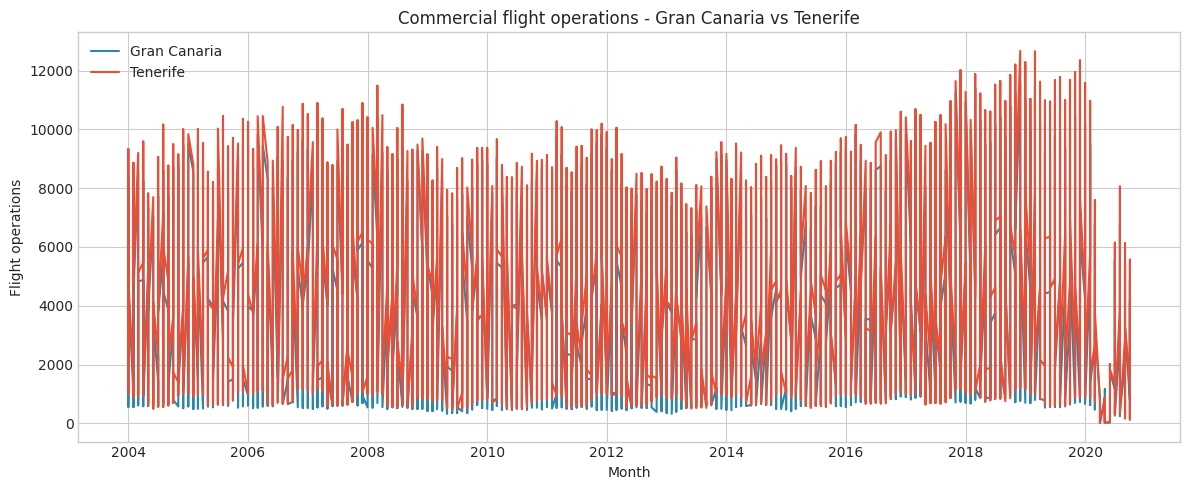

Saved: output/figures/airport_flights_gc_vs_tenerife.png


In [3]:
# 1. Gran Canaria vs Tenerife - monthly trend
fig, ax = plt.subplots(figsize=(12, 5))
colors = {"Gran Canaria": "#2E86AB", "Tenerife": "#E94F37"}

for isl, color in colors.items():
    d = flights[flights["island"] == isl].sort_values("date")
    ax.plot(d["date"], d["operations"], label=isl, color=color, linewidth=1.5)

ax.set_xlabel("Month")
ax.set_ylabel("Flight operations")
ax.set_title("Commercial flight operations - Gran Canaria vs Tenerife")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "airport_flights_gc_vs_tenerife.png", dpi=150)
plt.show()
print("Saved: output/figures/airport_flights_gc_vs_tenerife.png")

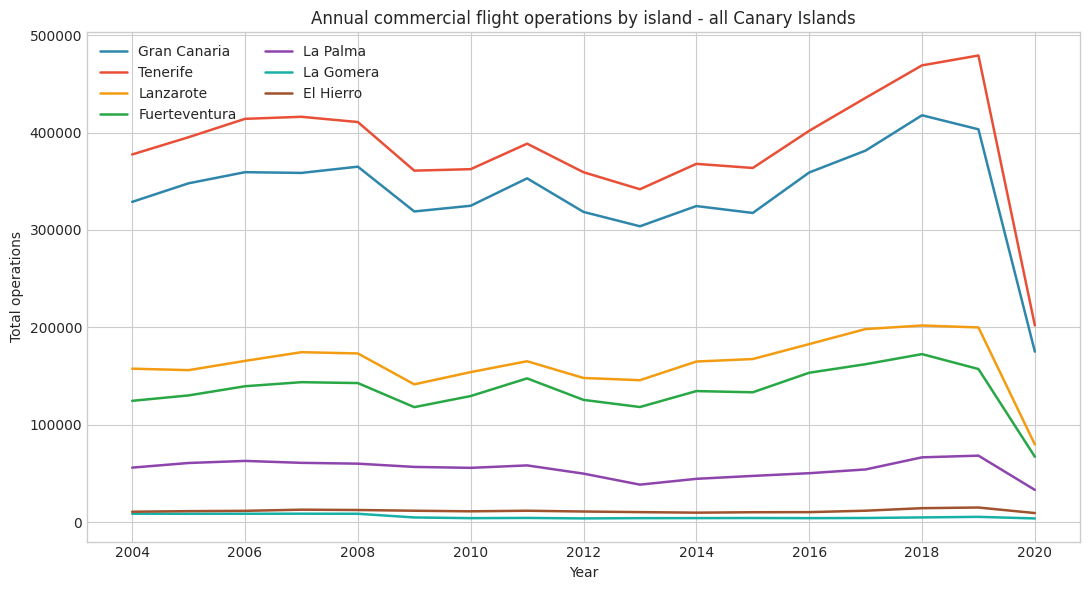

Saved: output/figures/airport_flights_all_islands_trend.png


In [4]:
# 2. All islands - annual total operations
annual = flights.groupby(["year", "island"])["operations"].sum().reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
all_islands = ["Gran Canaria", "Tenerife", "Lanzarote", "Fuerteventura",
              "La Palma", "La Gomera", "El Hierro"]
colors7 = {
    "Gran Canaria": "#2E86AB", "Tenerife": "#E94F37",
    "Lanzarote": "#F39C12", "Fuerteventura": "#28A745",
    "La Palma": "#8E44AD", "La Gomera": "#17B0A7", "El Hierro": "#A0522D"
}
for isl in all_islands:
    d = annual[annual["island"] == isl]
    ax.plot(d["year"], d["operations"], label=isl, color=colors7[isl], linewidth=1.8)

ax.set_xlabel("Year")
ax.set_ylabel("Total operations")
ax.set_title("Annual commercial flight operations by island - all Canary Islands")
ax.legend(loc="upper left", ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "airport_flights_all_islands_trend.png", dpi=150)
plt.show()
print("Saved: output/figures/airport_flights_all_islands_trend.png")

2019 vs 2020 annual operations:
                    2019      2020  change_pct
island                                        
Canarias       1328251.0  570263.0       -57.1
Tenerife        479081.0  201978.0       -57.8
Gran Canaria    403288.0  175101.0       -56.6
Lanzarote       199913.0   79717.0       -60.1
Fuerteventura   157201.0   67162.0       -57.3
La Palma         68283.0   33130.0       -51.5
El Hierro        15031.0    9348.0       -37.8
La Gomera         5454.0    3827.0       -29.8


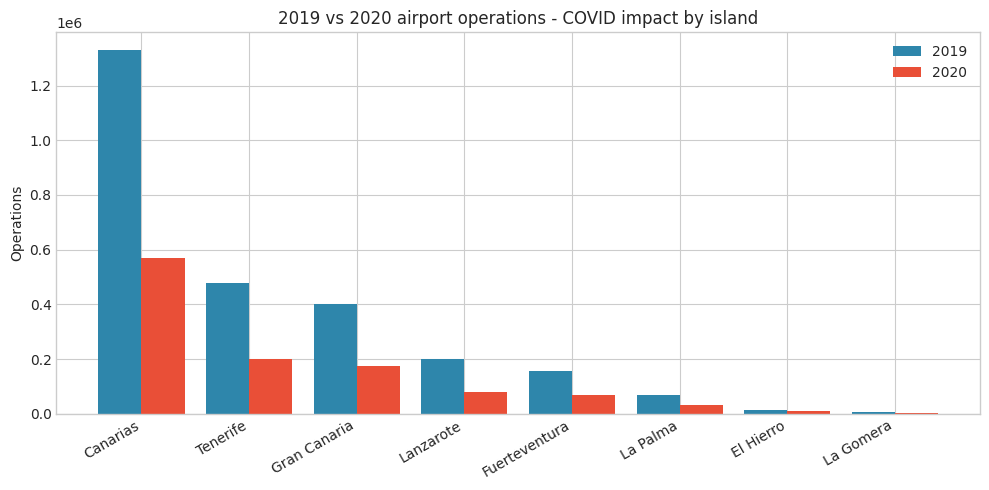

Saved: output/figures/airport_flights_2019_vs_2020.png


In [5]:
# 3. 2019 vs 2020 COVID impact
annual19 = annual[annual["year"] == 2019].set_index("island")["operations"]
annual20 = annual[annual["year"] == 2020].set_index("island")["operations"]

comparison = pd.DataFrame({"2019": annual19, "2020": annual20})
comparison["change_pct"] = ((comparison["2020"] - comparison["2019"]) / comparison["2019"] * 100).round(1)
comparison = comparison.sort_values("2019", ascending=False)
print("2019 vs 2020 annual operations:")
print(comparison)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(comparison))
ax.bar(x, comparison["2019"], color="#2E86AB", label="2019", width=0.4)
ax.bar([i + 0.4 for i in x], comparison["2020"], color="#E94F37", label="2020", width=0.4)
ax.set_xticks([i + 0.2 for i in x])
ax.set_xticklabels(comparison.index, rotation=30, ha="right")
ax.set_ylabel("Operations")
ax.set_title("2019 vs 2020 airport operations - COVID impact by island")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "airport_flights_2019_vs_2020.png", dpi=150)
plt.show()
print("Saved: output/figures/airport_flights_2019_vs_2020.png")

In [6]:
# 4. Key numbers - 2019 totals
print("2019 annual operations:")
for isl in ["Gran Canaria", "Tenerife", "Lanzarote", "Fuerteventura"]:
    val = annual[(annual["year"]==2019) & (annual["island"]==isl)]["operations"].values[0]
    print("  " + isl + ": " + str(int(val)) + " operations")
print()
print("COVID drop 2019->2020:")
for _, row in comparison.iterrows():
    print("  " + row.name + ": " + str(row["change_pct"]) + "%")

2019 annual operations:
  Gran Canaria: 403288 operations
  Tenerife: 479081 operations
  Lanzarote: 199913 operations
  Fuerteventura: 157201 operations

COVID drop 2019->2020:
  Canarias: -57.1%
  Tenerife: -57.8%
  Gran Canaria: -56.6%
  Lanzarote: -60.1%
  Fuerteventura: -57.3%
  La Palma: -51.5%
  El Hierro: -37.8%
  La Gomera: -29.8%
